# Regresión One vs All de dataset no grafico

## Preparar Datos

In [1]:
# Importar librerías
import os
import numpy as np
from matplotlib import pyplot
from scipy import optimize
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
# Cargar dataset balanceado (50k x clase)
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

chunks = []
counts = {1: 0, 2: 0, 3: 0, 4: 0}
target = 50000

for chunk in pd.read_csv(f"{path}/US_Accidents_March23.csv", chunksize=100000):
    for clase in [1, 2, 3, 4]:
        if counts[clase] < target:
            sub = chunk[chunk['Severity'] == clase]
            needed = target - counts[clase]
            chunks.append(sub.head(needed))
            counts[clase] += len(sub.head(needed))

    if all(v >= target for v in counts.values()):
        print("✅ Se obtuvieron 50k de cada clase")
        break

    print(f"Progreso: {counts}")

df_bal = pd.concat(chunks).reset_index(drop=True)
print(f"\n📦 Dataset completo: {df_bal.shape[0]} filas x {df_bal.shape[1]} columnas")
print(df_bal['Severity'].value_counts())

100%|██████████| 653M/653M [00:05<00:00, 120MB/s] 

Extracting files...


Progreso: {1: 98, 2: 50000, 3: 44844, 4: 33}
Progreso: {1: 154, 2: 50000, 3: 50000, 4: 130}
Progreso: {1: 226, 2: 50000, 3: 50000, 4: 164}
Progreso: {1: 319, 2: 50000, 3: 50000, 4: 200}
Progreso: {1: 388, 2: 50000, 3: 50000, 4: 280}
Progreso: {1: 28881, 2: 50000, 3: 50000, 4: 928}
Progreso: {1: 38233, 2: 50000, 3: 50000, 4: 1465}
Progreso: {1: 38298, 2: 50000, 3: 50000, 4: 1922}
Progreso: {1: 38339, 2: 50000, 3: 50000, 4: 2387}
Progreso: {1: 38381, 2: 50000, 3: 50000, 4: 3197}
Progreso: {1: 38403, 2: 50000, 3: 50000, 4: 4271}
Progreso: {1: 38424, 2: 50000, 3: 50000, 4: 5396}
Progreso: {1: 38449, 2: 50000, 3: 50000, 4: 6393}
Progreso: {1: 38484, 2: 50000, 3: 50000, 4: 7488}
Progreso: {1: 38500, 2: 50000, 3: 50000, 4: 8572}
Progreso: {1: 38558, 2: 50000, 3: 50000, 4: 9403}
Progreso: {1: 38604, 2: 50000, 3: 50000, 4: 10141}
Progreso: {1: 38636, 2: 50000, 3: 50000, 4: 10843}
Progreso: {1: 38674, 2: 50000, 3: 50000, 4: 11520}
Progreso: {1: 38694, 2: 50000, 3: 50000, 4: 12177}
Progreso: {1: 

In [3]:
# Split 80% train / 20% test
train, test = train_test_split(df_bal, test_size=0.2,
                               random_state=42,
                               stratify=df_bal['Severity'])

print(f"🟢 Train (80%): {train.shape[0]} filas x {train.shape[1]} columnas")
print(train['Severity'].value_counts())

print(f"\n🔴 Test  (20%): {test.shape[0]} filas x {test.shape[1]} columnas")
print(test['Severity'].value_counts())

# Guardar
df_bal.to_csv('us_accidents_balanced_200k.csv', index=False)
train.to_csv('us_accidents_train_160k.csv',     index=False)
test.to_csv('us_accidents_test_40k.csv',        index=False)
print("\n✅ Archivos guardados")

🟢 Train (80%): 160000 filas x 46 columnas
Severity
2    40000
3    40000
4    40000
1    40000
Name: count, dtype: int64

🔴 Test  (20%): 40000 filas x 46 columnas
Severity
4    10000
2    10000
3    10000
1    10000
Name: count, dtype: int64

✅ Archivos guardados


In [4]:
# Preprocesamiento
df = pd.read_csv('/content/us_accidents_train_160k.csv')

# Eliminar columnas no útiles
drop_cols = ['ID', 'Source', 'Description', 'Street', 'City', 'County',
             'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code',
             'Weather_Timestamp', 'Start_Time', 'End_Time']
df = df.drop(columns=drop_cols)

# Codificar columnas categóricas
cat_cols = ['Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset',
            'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Convertir booleanos a 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# Rellenar nulos con la media
df = df.fillna(df.mean(numeric_only=True))

print(f"✅ Columnas después del preprocesamiento: {df.shape[1]}")
print(df.dtypes)

✅ Columnas después del preprocesamiento: 127
Severity                                  int64
Start_Lat                               float64
Start_Lng                               float64
End_Lat                                 float64
End_Lng                                 float64
                                         ...   
Weather_Condition_Wintry Mix / Windy      int64
Sunrise_Sunset_Night                      int64
Civil_Twilight_Night                      int64
Nautical_Twilight_Night                   int64
Astronomical_Twilight_Night               int64
Length: 127, dtype: object


In [5]:
# Ver si hay columnas que siguen siendo object (texto)
cols_object = df.select_dtypes(include='object').columns
print(f"Columnas tipo object: {len(cols_object)}")
print(cols_object.tolist())

Columnas tipo object: 0
[]


In [6]:
# Definir X, y y parámetros del modelo

# Parámetros
input_layer_size = df.shape[1] - 1  # número real de features tras preprocesamiento
num_labels = 4                       # clases: 0, 1, 2, 3

# Separar X e y
X = df.drop(columns=['Severity']).values
y = df['Severity'].values - 1  # Severity 1-4 → clases 0-3

m = y.size

print(f"input_layer_size : {input_layer_size}")
print(f"num_labels       : {num_labels}")
print(f"X shape          : {X.shape}")
print(f"y shape          : {y.shape}")
print(f"m                : {m}")
print(f"Clases únicas    : {np.unique(y)}")

input_layer_size : 126
num_labels       : 4
X shape          : (160000, 126)
y shape          : (160000,)
m                : 160000
Clases únicas    : [0 1 2 3]


In [7]:
# Verificar primera fila
print("Primera fila de X:")
print(X[0, :])

print("\nVector y (clases):")
print(y)

Primera fila de X:
[ 3.95093730e+01 -1.21650780e+02  3.76222033e+01 -9.16355022e+01
  0.00000000e+00  7.30000000e+01  6.53215062e+01  4.90000000e+01
  3.00300000e+01  1.00000000e+01  4.60000000e+00  9.29389650e-03
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00

## Funciones del modelo

In [8]:
# Normalización de features
def featureNormalize(X):
    X_norm = X.copy().astype(float)

    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero en columnas constantes (sigma=0)
    sigma_safe = np.where(sigma == 0, 1, sigma)

    X_norm = (X - mu) / sigma_safe

    return X_norm, mu, sigma

In [9]:
# Aplicar normalización a X
X_norm, mu, sigma = featureNormalize(X)

In [10]:
# Datos normalizados
print("Primera fila de X_norm:")
print(X_norm[0,:])

print("\nVector y (clases):")
print(y)

Primera fila de X_norm:
[ 9.21611762e-01 -9.21953551e-01  3.18530291e-15  5.41769175e-15
 -2.59173703e-01  4.09798712e-01 -1.08551618e-15 -6.00067392e-01
  4.00696552e-01  3.17115330e-01 -6.81929611e-01  3.47755097e-17
 -1.03259330e-01 -1.96888348e-02 -3.45596475e-01 -6.41137870e-02
 -3.03464222e-01 -4.29055081e-02 -1.08863715e-01 -5.00006250e-03
 -1.68650150e-01 -1.84587907e-01 -2.85159726e-02 -4.37673180e-01
  0.00000000e+00 -3.97452681e-01 -1.32071135e-01 -1.52319022e-01
 -1.68100595e-01  7.22192122e+00 -1.31555822e-01 -1.48208904e-01
 -1.45454799e-01 -1.86874703e-01 -2.14375193e-01 -1.69022158e-01
 -1.74479669e-01 -1.82239637e-01 -1.93820505e-01 -2.57316439e-01
 -2.53679861e-01 -2.11746425e-01 -1.30469968e-01 -1.99122169e-01
 -1.57605674e-01 -2.51397360e-01 -2.50694039e-01 -2.77185787e-01
 -2.50000781e-03 -2.50000781e-03 -8.66057882e-03 -7.14844027e-01
 -2.18049238e-01 -2.48823851e-02 -2.03142863e-02 -3.53555600e-03
 -4.69612085e-01 -4.16443565e-02 -7.66275179e-02 -4.33016761e-03
 

In [11]:
# Configurar matriz X
# Obtener dimensiones
m, n = X.shape

# Usar X normalizada (sin término de intercepción por ahora)
X = X_norm

## Función de Costo

In [12]:
# Función Sigmoide
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    Clip para evitar valores exactos de 0 o 1 que causan log(0) = -inf.
    """
    return np.clip(1.0 / (1.0 + np.exp(-z)), 1e-10, 1 - 1e-10)

In [13]:
# Función de Costo (sin regularización)
def calcularCosto(theta, X, y):
    """
    Calcula el costo de la regresión logística binaria.
    Usado internamente para monitorear la convergencia.
    """
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

In [14]:
# Descenso por Gradiente (sin regularización)
def descensoGradiente(theta, X, y, alpha, num_iters):
    """
    Actualiza theta iterativamente usando descenso por gradiente.
    Registra el costo en cada iteración para graficar convergencia.
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

In [15]:
# Función de Costo Regularizada (L2)
def lrCostFunction(theta, X, y, lambda_):
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))

    # Clip adicional por seguridad
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp    = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \
        + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

## Clasificación one vs all

In [16]:
# One vs All con Descenso por Gradiente
def OneVsAll(X, y, num_labels, lambda_):
    """
    Entrena num_labels clasificadores binarios usando descenso
    por gradiente. Uno por cada clase de Severity (0,1,2,3).
    Grafica la convergencia del costo por cada clasificador.
    """
    alpha     = 0.001
    num_iters = 100

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))

    # Agregar término de intercepción
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    pyplot.figure(figsize=(12, 8))
    clases = ['Severity 1 (leve)', 'Severity 2 (moderado)',
              'Severity 3 (grave)', 'Severity 4 (muy grave)']

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)

        # Etiqueta binaria: 1 si es clase c, 0 si no
        y_actual = np.where(y == c, 1, 0)

        theta, J_history = descensoGradiente(initial_theta, X, y_actual,
                                             alpha, num_iters)
        all_theta[c] = theta

        # Grafica convergencia de costo por clase
        pyplot.plot(np.arange(len(J_history)), J_history,
                    lw=2, label=clases[c])

    pyplot.xlabel('Número de iteraciones')
    pyplot.ylabel('Costo J')
    pyplot.title('Convergencia del Costo — One vs All (Gradiente)')
    pyplot.legend()
    pyplot.grid(True)
    pyplot.show()

    return all_theta

In [17]:
# One vs All con scipy.optimize (recomendado)
def OneVsAllOM(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta   = np.zeros((num_labels, n + 1))
    all_history = {c: [] for c in range(num_labels)}  # historial por clase

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    clases = ['Severity 1 (leve)', 'Severity 2 (moderado)',
              'Severity 3 (grave)', 'Severity 4 (muy grave)']

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)

        # Callback para guardar costo en cada iteración
        def callback(theta_actual):
            J, _ = lrCostFunction(theta_actual,
                                  X, (y == c).astype(int), lambda_)
            all_history[c].append(J)

        options = {'maxiter': 100}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                callback=callback,
                                options=options)

        all_theta[c] = res.x
        print(f"✅ Clase {c} ({clases[c]}) — Costo final: {res.fun:.4f}")

    return all_theta, all_history

In [18]:
# Entrenar modelo
lambda_ = 0.1
all_theta, all_history = OneVsAllOM(X, y, num_labels, lambda_)

print(f"\nall_theta shape: {all_theta.shape}")  # (4, 127)

✅ Clase 0 (Severity 1 (leve)) — Costo final: 0.1653
✅ Clase 1 (Severity 2 (moderado)) — Costo final: 0.3440
✅ Clase 2 (Severity 3 (grave)) — Costo final: 0.3288
✅ Clase 3 (Severity 4 (muy grave)) — Costo final: 0.2091

all_theta shape: (4, 127)


## Predicción one vs all

In [19]:
# Predicción One vs All
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada accidente en X.
    Para cada ejemplo, calcula la probabilidad de pertenecer a cada
    clase de Severity (0,1,2,3) y asigna la clase con mayor probabilidad.

    Parámetros
    ----------
    all_theta : array_like (4 x n+1)
        Thetas entrenados para cada clase de Severity.

    X : array_like (m x n)
        Features normalizadas del set a predecir (sin término de intercepción).

    Retorna
    -------
    p : array_like (m,)
        Predicciones: 0=Severity1, 1=Severity2, 2=Severity3, 3=Severity4
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Agregar término de intercepción
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calcular probabilidades para cada clase y tomar la mayor
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

In [20]:
# Precisión en entrenamiento y prueba
# ── Precisión en ENTRENAMIENTO (80%) ───────────
print(f"X train shape: {X.shape}")
pred_train = predictOneVsAll(all_theta, X)
precision_train = np.mean(pred_train == y) * 100
print(f"Precisión en entrenamiento (80%): {precision_train:.2f}%")

# ── Cargar y preprocesar datos de PRUEBA (20%) ─
df_test = pd.read_csv('/content/us_accidents_test_40k.csv')

# Aplicar mismo preprocesamiento que al train
df_test = df_test.drop(columns=drop_cols, errors='ignore')
df_test = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)
bool_cols_test = df_test.select_dtypes(include='bool').columns
df_test[bool_cols_test] = df_test[bool_cols_test].astype(int)
df_test = df_test.fillna(df_test.mean(numeric_only=True))

# Alinear columnas con el train (por si get_dummies generó columnas distintas)
df_test = df_test.reindex(columns=df.columns, fill_value=0)

# Separar X_test e y_test
X_test = df_test.drop(columns=['Severity']).values
y_test = df_test['Severity'].values - 1  # clases 0-3

# Normalizar con mu y sigma del TRAIN
X_test_norm = (X_test - mu) / np.where(sigma == 0, 1, sigma)

print(f"\nX test shape: {X_test_norm.shape}")   # (40000, 126)
print(f"Clases únicas test: {np.unique(y_test)}")

# ── Precisión en PRUEBA (20%) ──────────────────
pred_test = predictOneVsAll(all_theta, X_test_norm)
precision_test = np.mean(pred_test == y_test) * 100
print(f"Precisión en prueba      (20%): {precision_test:.2f}%")

# ── Resumen comparativo ────────────────────────
print(f"\n{'='*45}")
print(f"  Precisión ENTRENAMIENTO (80%): {precision_train:.2f}%")
print(f"  Precisión PRUEBA        (20%): {precision_test:.2f}%")
print(f"  Diferencia                   : {abs(precision_train - precision_test):.2f}%")
print(f"{'='*45}")

X train shape: (160000, 126)
Precisión en entrenamiento (80%): 76.55%

X test shape: (40000, 126)
Clases únicas test: [0 1 2 3]
Precisión en prueba      (20%): 76.33%

  Precisión ENTRENAMIENTO (80%): 76.55%
  Precisión PRUEBA        (20%): 76.33%
  Diferencia                   : 0.23%


## Gráfico de costo

Severity 1: Costo = 0.1653
Severity 2: Costo = 0.3440
Severity 3: Costo = 0.3288
Severity 4: Costo = 0.2091


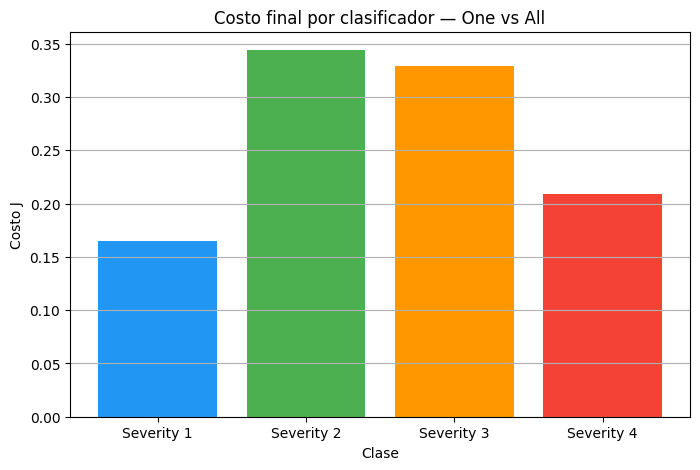

In [21]:
# Mostrar costo final por clase
clases = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
costos = []
m_x = X.shape[0]
X_bias = np.concatenate([np.ones((m_x, 1)), X], axis=1)

for c in range(num_labels):
    y_c = (y == c).astype(int)
    J, _ = lrCostFunction(all_theta[c], X_bias, y_c, lambda_)
    costos.append(J)
    print(f"{clases[c]}: Costo = {J:.4f}")

pyplot.figure(figsize=(8, 5))
pyplot.bar(clases, costos, color=['#2196F3','#4CAF50','#FF9800','#F44336'])
pyplot.xlabel('Clase')
pyplot.ylabel('Costo J')
pyplot.title('Costo final por clasificador — One vs All')
pyplot.grid(axis='y')
pyplot.show()

## Gráfica de Precision

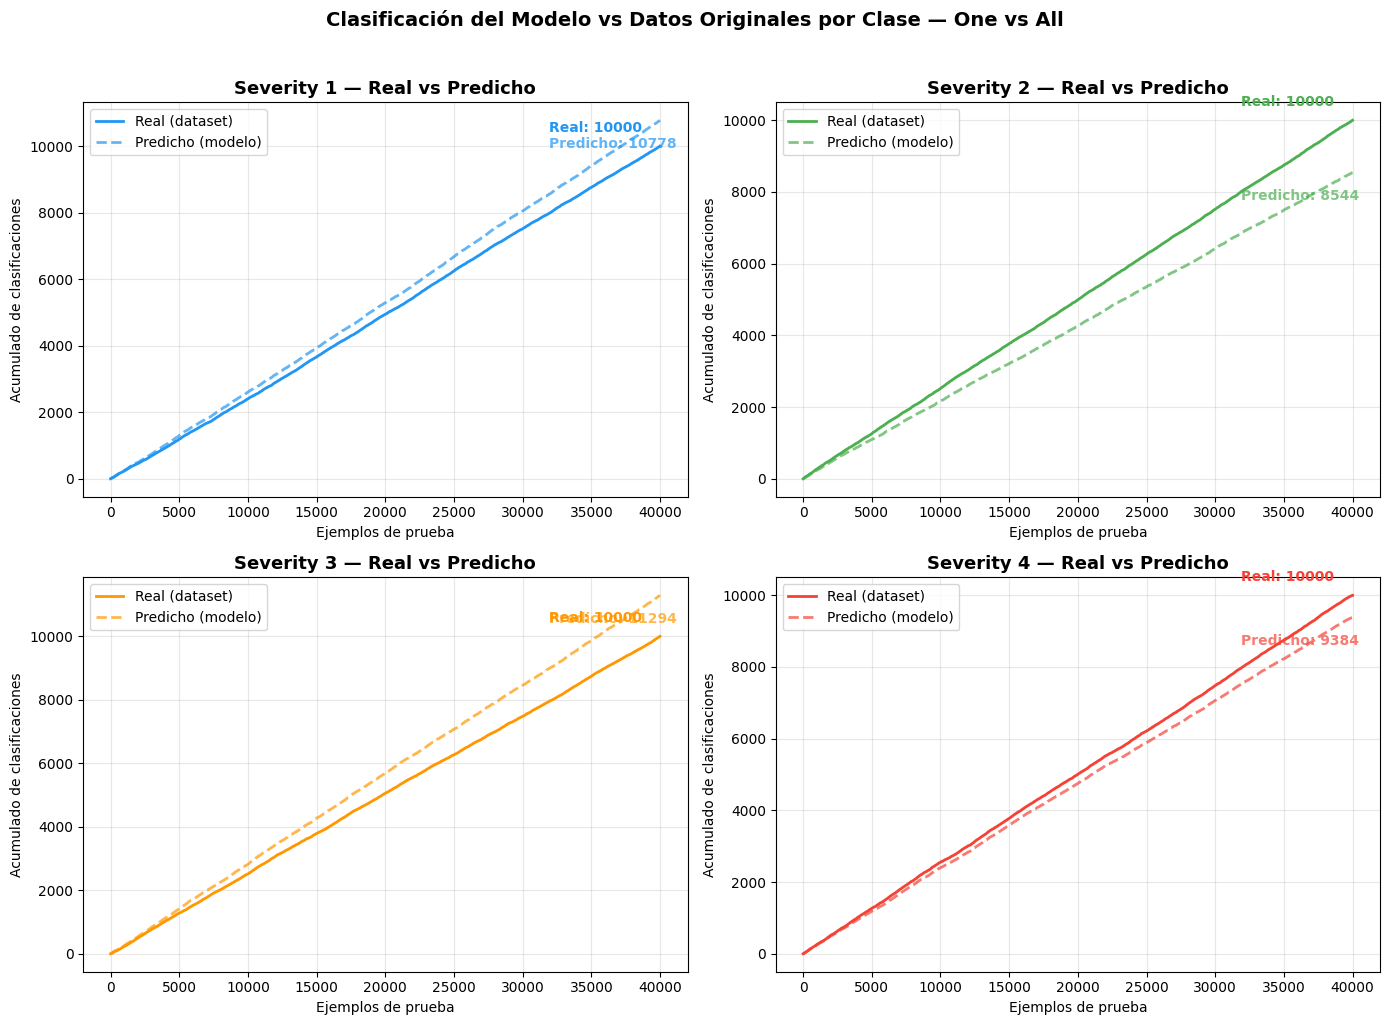

In [22]:
# Gráfica de líneas por clase — Predicho vs Real
clases  = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, axes = pyplot.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (clase, color) in enumerate(zip(clases, colores)):
    # Contar real vs predicho para esta clase (ejemplo por ejemplo)
    real_c     = (y_test == i).astype(int)
    predicho_c = (pred_test == i).astype(int)

    # Acumulado a lo largo del set de prueba
    real_acum     = np.cumsum(real_c)
    predicho_acum = np.cumsum(predicho_c)

    x = np.arange(len(y_test))

    axes[i].plot(x, real_acum,     lw=2, label='Real (dataset)',   color=color,  linestyle='-')
    axes[i].plot(x, predicho_acum, lw=2, label='Predicho (modelo)', color=color, linestyle='--', alpha=0.7)

    # Totales finales
    axes[i].annotate(f'Real: {real_acum[-1]}',
                     xy=(len(y_test)-1, real_acum[-1]),
                     xytext=(-80, 10), textcoords='offset points',
                     color=color, fontweight='bold')
    axes[i].annotate(f'Predicho: {predicho_acum[-1]}',
                     xy=(len(y_test)-1, predicho_acum[-1]),
                     xytext=(-80, -20), textcoords='offset points',
                     color=color, fontweight='bold', alpha=0.7)

    axes[i].set_title(f'{clase} — Real vs Predicho', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Ejemplos de prueba')
    axes[i].set_ylabel('Acumulado de clasificaciones')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

pyplot.suptitle('Clasificación del Modelo vs Datos Originales por Clase — One vs All',
                fontsize=14, fontweight='bold', y=1.02)
pyplot.tight_layout()
pyplot.show()

## Gráfico descenso de gradiente

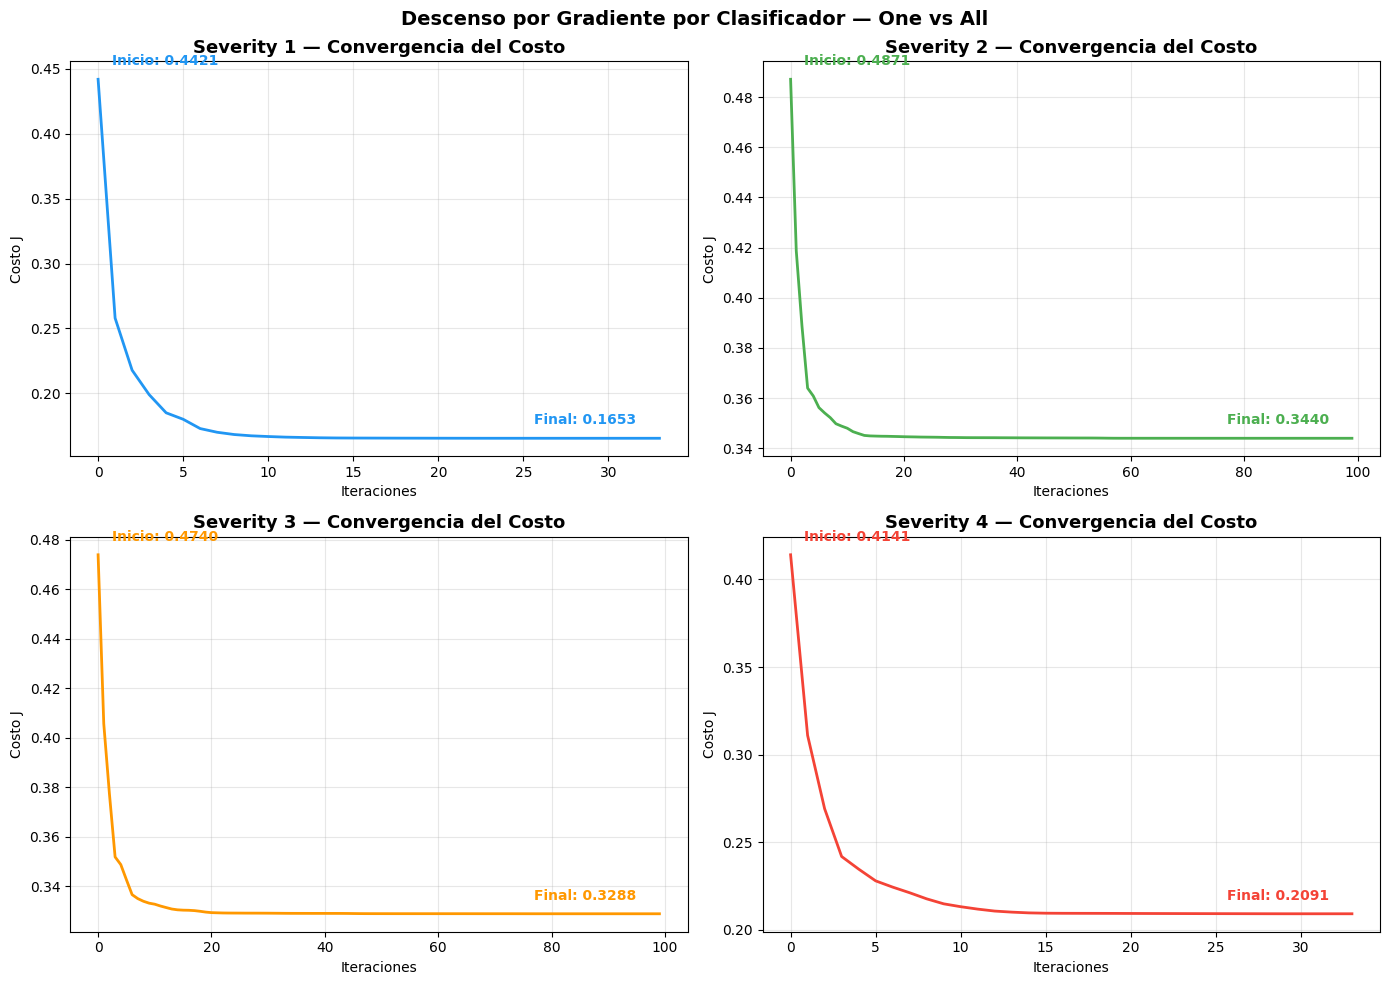

In [23]:
# ── Gráfica descenso de gradiente por clase ────
clases  = ['Severity 1', 'Severity 2', 'Severity 3', 'Severity 4']
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

fig, axes = pyplot.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for c, (clase, color) in enumerate(zip(clases, colores)):
    history = all_history[c]
    iters   = np.arange(len(history))

    axes[c].plot(iters, history, lw=2, color=color)
    axes[c].set_title(f'{clase} — Convergencia del Costo',
                      fontsize=13, fontweight='bold')
    axes[c].set_xlabel('Iteraciones')
    axes[c].set_ylabel('Costo J')
    axes[c].grid(True, alpha=0.3)

    # Anotar inicio y fin
    axes[c].annotate(f'Inicio: {history[0]:.4f}',
                     xy=(0, history[0]),
                     xytext=(10, 10), textcoords='offset points',
                     color=color, fontweight='bold')
    axes[c].annotate(f'Final: {history[-1]:.4f}',
                     xy=(iters[-1], history[-1]),
                     xytext=(-90, 10), textcoords='offset points',
                     color=color, fontweight='bold')

pyplot.suptitle('Descenso por Gradiente por Clasificador — One vs All',
                fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()